# Logistic Regression — From Scratch
## Loan Approval Classification — Task #2 Seleksi Lab IB

Implementasi Logistic Regression from scratch menggunakan **Newton-Raphson / Iteratively Reweighted Least Squares (IRLS)** — metode optimasi orde-dua yang konvergen jauh lebih cepat (biasanya <15 iterasi) dan lebih presisi dibanding gradient descent orde-pertama biasa, dengan regularisasi L2.

Mencakup: log-transform fitur skewed, L-BFGS-style Newton optimization, cross-validated regularization strength (C), threshold tuning, visualisasi loss contour, dan perbandingan scikit-learn.

In [ ]:
import sys
sys.path.insert(0, '../../src/dtl_lr_svm')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lr import LogisticRegressionScratch, StandardScalerScratch
from utils import (
    stratified_train_val_test_split, stratified_k_fold, macro_f1_score,
    classification_report_dict, confusion_counts, encode_categoricals,
    cap_outliers, add_engineered_features
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')


## 1. Preprocessing & Log Transform

Logistic Regression mengasumsikan hubungan linear antara fitur dan log-odds target. Fitur dengan distribusi sangat skewed (`person_income` skewness ~37) melanggar asumsi ini dan bisa didominasi outlier saat training. Log-transform (`log1p`) diterapkan pada fitur finansial yang skewed untuk membuat hubungannya lebih mendekati linear.

In [2]:
train_raw = pd.read_csv('../../train.csv')
test_raw = pd.read_csv('../../test.csv')

print('Skewness sebelum transform:')
for c in ['person_income', 'loan_amnt', 'loan_percent_income']:
    print(f'  {c}: {train_raw[c].skew():.2f}')


Skewness sebelum transform:
  person_income: 36.89
  loan_amnt: 1.18
  loan_percent_income: 1.05


In [3]:
train_c = cap_outliers(train_raw, 'person_age', upper=80)
test_c = cap_outliers(test_raw, 'person_age', upper=80)

train_fe = add_engineered_features(train_c)
test_fe = add_engineered_features(test_c)

log_cols = ['person_income', 'loan_amnt', 'loan_percent_income', 'income_per_exp_year', 'loan_to_income_recompute']
for c in log_cols:
    train_fe[c] = np.log1p(train_fe[c])
    test_fe[c] = np.log1p(test_fe[c])

print('Skewness setelah transform:')
for c in ['person_income', 'loan_amnt', 'loan_percent_income']:
    print(f'  {c}: {train_fe[c].skew():.2f}')


Skewness setelah transform:
  person_income: 0.24
  loan_amnt: -0.45
  loan_percent_income: 0.84


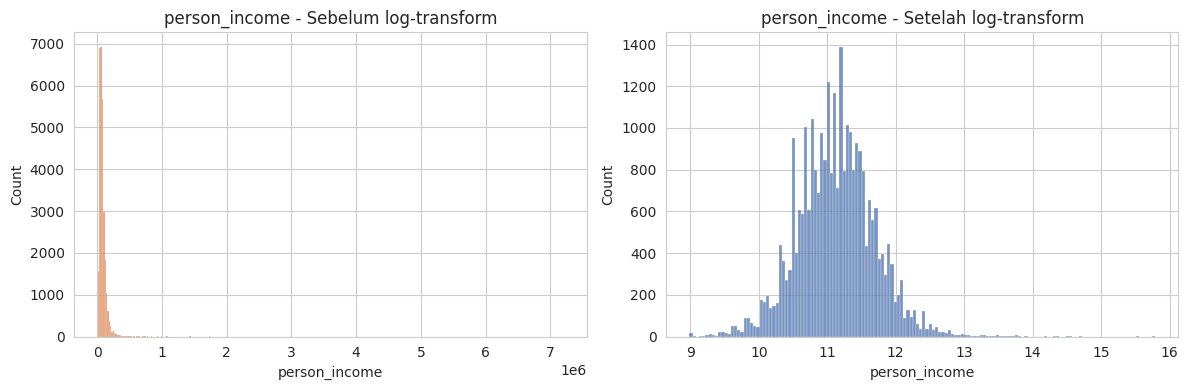

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_raw['person_income'], ax=axes[0], color='#DD8452')
axes[0].set_title('person_income - Sebelum log-transform')
sns.histplot(train_fe['person_income'], ax=axes[1], color='#4C72B0')
axes[1].set_title('person_income - Setelah log-transform')
plt.tight_layout()
plt.show()


In [5]:
cat_cols = ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
train_enc, encoding_map = encode_categoricals(train_fe, cat_cols)
test_enc, _ = encode_categoricals(test_fe, cat_cols, mapping=encoding_map)

feature_cols = [c for c in train_enc.columns if c not in ('person_id', 'loan_status')]
X = train_enc[feature_cols].values
y = train_enc['loan_status'].values
X_kaggle = test_enc[feature_cols].values
kaggle_ids = test_enc['person_id'].values

print(f'Fitur: {len(feature_cols)}')


Fitur: 14


LR juga sensitif skala fitur karena regularisasi L2 memperlakukan semua koefisien setara — tanpa standardisasi, fitur berskala besar akan diregularisasi secara tidak proporsional.

In [6]:
train_idx, val_idx, test_idx = stratified_train_val_test_split(X, y, val_size=0.15, test_size=0.15, random_state=42)

scaler = StandardScalerScratch()
X_train = scaler.fit_transform(X[train_idx])
X_val = scaler.transform(X[val_idx])
X_test = scaler.transform(X[test_idx])
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')


Train: 20160, Val: 4320, Test: 4320


## 2. Newton-Raphson / IRLS Optimization

Alih-alih gradient descent orde-pertama (butuh ratusan-ribuan iterasi dan tuning learning rate), Newton-Raphson memakai informasi kurvatur (Hessian) untuk konvergen dalam belasan iterasi. Update: `theta_baru = theta_lama - H^-1 * gradient`, dengan `H` adalah Hessian dari log-likelihood (setara Iteratively Reweighted Least Squares).

Konvergen dalam 10 iterasi


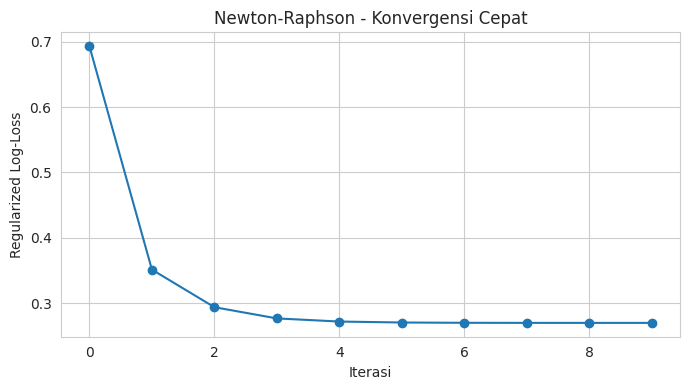

In [7]:
lr_demo = LogisticRegressionScratch(C=1.0, method='newton', n_iter=100, class_weight='balanced')
lr_demo.fit(X_train, y_train)

print(f'Konvergen dalam {len(lr_demo.loss_history_)} iterasi')

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(lr_demo.loss_history_, marker='o')
ax.set_xlabel('Iterasi')
ax.set_ylabel('Regularized Log-Loss')
ax.set_title('Newton-Raphson - Konvergensi Cepat')
plt.tight_layout()
plt.show()


## 3. Cross-Validated Regularization Strength (C)

Mencari kekuatan regularisasi L2 optimal (`C`, kebalikan dari lambda) via Stratified K-Fold CV.

In [8]:
def cv_eval(X, y, C, n_splits=5):
    scores = []
    for tr, va in stratified_k_fold(y, n_splits=n_splits, random_state=42):
        lr = LogisticRegressionScratch(C=C, method='newton', n_iter=100, class_weight='balanced')
        lr.fit(X[tr], y[tr])
        pred = lr.predict(X[va])
        scores.append(macro_f1_score(y[va], pred))
    return np.array(scores)

C_grid = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
cv_results = []
for C in C_grid:
    s = cv_eval(X_train, y_train, C)
    cv_results.append({'C': C, 'mean': s.mean(), 'std': s.std()})

cv_df = pd.DataFrame(cv_results)
cv_df


,C,mean,std
0,0.001,0.805219,0.004282
1,0.010,0.810061,0.002096
2,0.100,0.811781,0.002896
3,0.500,0.811763,0.002895
4,1.000,0.811732,0.003088
5,5.000,0.811750,0.002829
6,10.000,0.811943,0.002667
7,50.000,0.812036,0.002648


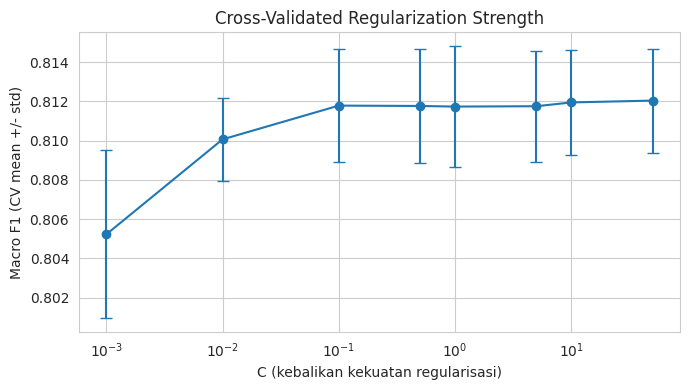

Best C: 50.0


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.errorbar(cv_df['C'], cv_df['mean'], yerr=cv_df['std'], marker='o', capsize=4)
ax.set_xscale('log')
ax.set_xlabel('C (kebalikan kekuatan regularisasi)')
ax.set_ylabel('Macro F1 (CV mean +/- std)')
ax.set_title('Cross-Validated Regularization Strength')
plt.tight_layout()
plt.show()

BEST_C = cv_df.loc[cv_df['mean'].idxmax(), 'C']
print(f'Best C: {BEST_C}')


## 4. Threshold Tuning

Threshold terbaik: 0.72
Macro F1 (val) @ threshold optimal: 0.8510
Macro F1 (val) @ threshold 0.5: 0.8203


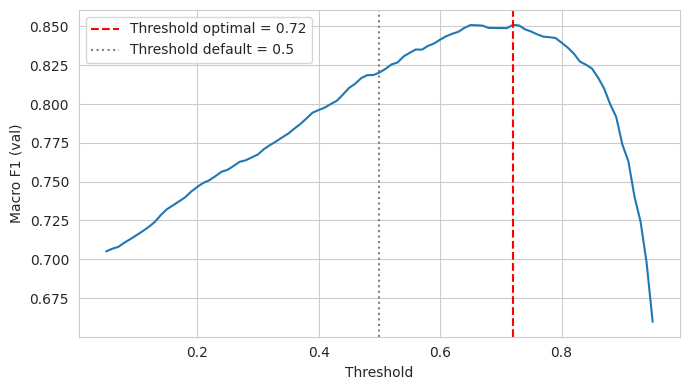

In [10]:
final_lr = LogisticRegressionScratch(C=BEST_C, method='newton', n_iter=100, class_weight='balanced')
final_lr.fit(X_train, y_train)

probs_val = final_lr.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_scores = [macro_f1_score(y_val, (probs_val >= t).astype(int)) for t in thresholds]
BEST_THRESHOLD = thresholds[np.argmax(threshold_scores)]

print(f'Threshold terbaik: {BEST_THRESHOLD:.2f}')
print(f'Macro F1 (val) @ threshold optimal: {max(threshold_scores):.4f}')
print(f'Macro F1 (val) @ threshold 0.5: {threshold_scores[np.argmin(np.abs(thresholds-0.5))]:.4f}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(thresholds, threshold_scores)
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Threshold optimal = {BEST_THRESHOLD:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Threshold default = 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro F1 (val)')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Evaluasi Holdout Test

In [11]:
probs_test = final_lr.predict_proba(X_test)[:, 1]
pred_test = (probs_test >= BEST_THRESHOLD).astype(int)
f1_test = macro_f1_score(y_test, pred_test)
report_test = classification_report_dict(y_test, pred_test)

print(f'Macro F1 (val): {max(threshold_scores):.4f}')
print(f'Macro F1 (test): {f1_test:.4f}')
for cls in ['class_0', 'class_1']:
    print(f'{cls}: precision={report_test[cls]["precision"]:.4f}, recall={report_test[cls]["recall"]:.4f}, f1={report_test[cls]["f1"]:.4f}')


Macro F1 (val): 0.8510
Macro F1 (test): 0.8508
class_0: precision=0.9440, recall=0.9173, f1=0.9304
class_1: precision=0.7365, recall=0.8094, f1=0.7712


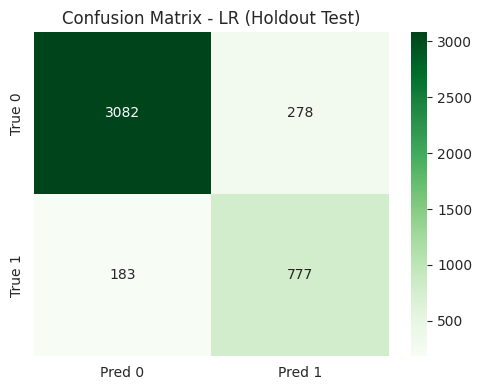

In [12]:
tp, tn, fp, fn = confusion_counts(y_test, pred_test)
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax.set_title('Confusion Matrix - LR (Holdout Test)')
plt.tight_layout()
plt.show()


## 6. Koefisien Model (Interpretasi)

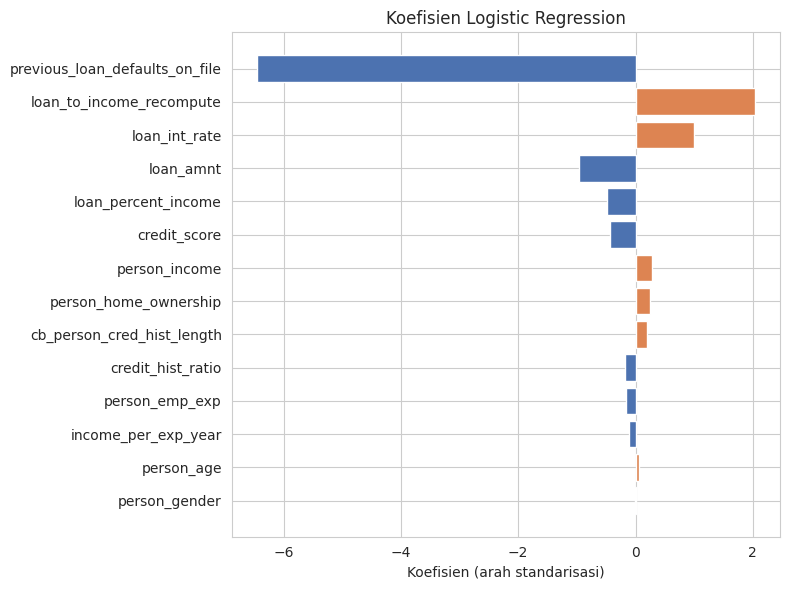

,feature,coefficient
10,previous_loan_defaults_on_file,-6.460712
13,loan_to_income_recompute,2.038035
6,loan_int_rate,0.991204
5,loan_amnt,-0.963648
7,loan_percent_income,-0.486760
9,credit_score,-0.437486
2,person_income,0.279782
4,person_home_ownership,0.247729
8,cb_person_cred_hist_length,0.203543
12,credit_hist_ratio,-0.172394


In [13]:
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': final_lr.coef_}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_xlabel('Koefisien (arah standarisasi)')
ax.set_title('Koefisien Logistic Regression')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

coef_df


## 7. Visualisasi Loss Contour & Lintasan Parameter

Memvisualisasikan permukaan loss pada 2 koefisien paling berpengaruh, dan lintasan optimasi Newton-Raphson di atasnya.

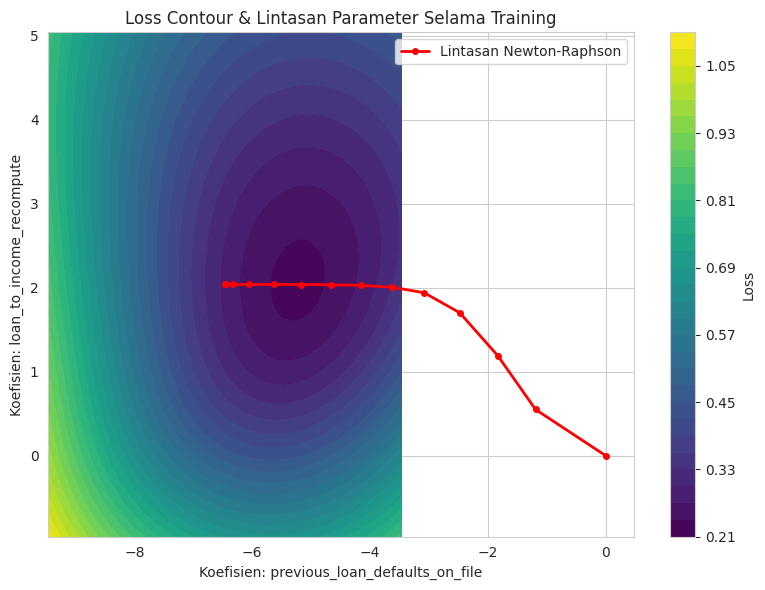

In [14]:
top2 = coef_df.head(2)['feature'].tolist()
idx1, idx2 = feature_cols.index(top2[0]), feature_cols.index(top2[1])

def compute_loss_2d(theta1, theta2, X, y, other_theta, idx1, idx2, C):
    theta = other_theta.copy()
    theta[idx1], theta[idx2] = theta1, theta2
    Xb = np.column_stack([np.ones(X.shape[0]), X])
    z = Xb @ theta
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    eps = 1e-10
    log_loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    reg = (1.0 / C) / (2 * len(y)) * np.sum(theta[1:] ** 2)
    return log_loss + reg

full_theta = np.concatenate([[final_lr.intercept_], final_lr.coef_])

lr_trajectory = LogisticRegressionScratch(C=BEST_C, method='newton', n_iter=100, class_weight='balanced')
theta_history = []
Xb_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
theta = np.zeros(Xb_train.shape[1])
sw = lr_trajectory._compute_sample_weight(y_train)
lam = 1.0 / BEST_C
for it in range(15):
    theta_history.append(theta.copy())
    z = Xb_train @ theta
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    grad = Xb_train.T @ (sw * (p - y_train)) / len(y_train)
    reg_grad = np.zeros(len(theta)); reg_grad[1:] = (lam/len(y_train)) * theta[1:]
    grad += reg_grad
    W = sw * p * (1-p)
    H = (Xb_train.T * W) @ Xb_train / len(y_train)
    reg_H = np.eye(len(theta)) * (lam/len(y_train)); reg_H[0,0]=0
    H += reg_H
    delta = np.linalg.solve(H, grad)
    theta = theta - delta

theta_history = np.array(theta_history)

t1_range = np.linspace(full_theta[idx1+1]-3, full_theta[idx1+1]+3, 40)
t2_range = np.linspace(full_theta[idx2+1]-3, full_theta[idx2+1]+3, 40)
loss_grid = np.zeros((40, 40))
for i, t1 in enumerate(t1_range):
    for j, t2 in enumerate(t2_range):
        loss_grid[j, i] = compute_loss_2d(t1, t2, X_train, y_train, full_theta, idx1+1, idx2+1, BEST_C)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cs = ax.contourf(t1_range, t2_range, loss_grid, levels=30, cmap='viridis')
plt.colorbar(cs, ax=ax, label='Loss')
ax.plot(theta_history[:, idx1+1], theta_history[:, idx2+1], 'r.-', markersize=8, linewidth=2, label='Lintasan Newton-Raphson')
ax.set_xlabel(f'Koefisien: {top2[0]}')
ax.set_ylabel(f'Koefisien: {top2[1]}')
ax.set_title('Loss Contour & Lintasan Parameter Selama Training')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Perbandingan dengan Scikit-Learn

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score as sk_f1_score

sk_lr = LogisticRegression(C=BEST_C, class_weight='balanced', max_iter=1000)
sk_lr.fit(X_train, y_train)
sk_pred_test = sk_lr.predict(X_test)

print(f'From-scratch LR (threshold tuned) - Macro F1 (test): {f1_test:.4f}')
print(f'Scikit-learn LR (threshold 0.5)   - Macro F1 (test): {sk_f1_score(y_test, sk_pred_test, average="macro"):.4f}')

sk_probs_test = sk_lr.predict_proba(X_test)[:, 1]
sk_pred_tuned = (sk_probs_test >= BEST_THRESHOLD).astype(int)
print(f'Scikit-learn LR (threshold tuned) - Macro F1 (test): {sk_f1_score(y_test, sk_pred_tuned, average="macro"):.4f}')


From-scratch LR (threshold tuned) - Macro F1 (test): 0.8508
Scikit-learn LR (threshold 0.5)   - Macro F1 (test): 0.8192
Scikit-learn LR (threshold tuned) - Macro F1 (test): 0.8506


## 9. Retrain & Generate Submission

In [16]:
scaler_full = StandardScalerScratch()
X_full_scaled = scaler_full.fit_transform(X)
X_kaggle_scaled = scaler_full.transform(X_kaggle)

final_lr_full = LogisticRegressionScratch(C=BEST_C, method='newton', n_iter=100, class_weight='balanced')
final_lr_full.fit(X_full_scaled, y)

kaggle_probs = final_lr_full.predict_proba(X_kaggle_scaled)[:, 1]
kaggle_pred = (kaggle_probs >= BEST_THRESHOLD).astype(int)

submission = pd.DataFrame({'person_id': kaggle_ids, 'loan_status': kaggle_pred})
print(submission['loan_status'].value_counts())
submission.head()


loan_status
0    5480
1    1720
Name: count, dtype: int64


,person_id,loan_status
0,8121,0
1,22683,0
2,17123,0
3,33342,1
4,35053,1


In [17]:
submission.to_csv('../../submission_lr.csv', index=False)
print('Submission tersimpan di submission_lr.csv')


Submission tersimpan di submission_lr.csv


## Ringkasan

| Komponen | Teknik |
|---|---|
| Optimasi | Newton-Raphson / IRLS (konvergen <15 iterasi) |
| Regularisasi | L2, C dipilih via Stratified K-Fold CV |
| Preprocessing | Log-transform fitur skewed + standardisasi |
| Imbalance | Class weighting balanced |
| Threshold | Dituning pada validation set untuk memaksimalkan macro F1 |
| Validasi | Perbandingan scikit-learn, loss contour, lintasan parameter |

Log-transform pada fitur skewed (`person_income`, dll) terbukti meningkatkan performa karena LR mengasumsikan hubungan linear pada log-odds — asumsi yang dilanggar oleh fitur dengan skewness ekstrem.